# Loan Approval Prediction
## Project Phase 1 — Problem Understanding

## Problem Statement

Banks and financial institutions receive many loan applications and need to decide whether each application should be approved or rejected.

The goal of this project is to build a Machine Learning model that uses information about a loan applicant to predict whether the loan application should be approved or rejected.

## Machine Learning Objective

The objective of this project is to create a supervised Machine Learning classification model that predicts the loan approval status of an applicant.

This is a binary classification problem because there are only two possible outcomes:

- Approved
- Rejected

 ## Target Variable

The target variable is:

Loan Approval Status

Possible values:

- Approved
- Rejected

The exact labels may depend on the dataset.

## Input Features

The model may use the following information about the applicant:

- no_of_dependents
- education
- self_employed
- income_annum
- loan_amount
- loan_term
- cibil_score
- residential_assets_value
- commercial_assets_value
- luxury_assets_value
- bank_asset_value


## Real-World Application

This model can be used by:

- Banks
- Financial institutions
- Loan companies
- FinTech companies
- Loan officers

The model can help support faster and more consistent loan decisions.

## Expected Outcome

After training, the model should take the information of a new loan applicant and predict whether the application belongs to the approved or rejected class.

## Basic Workflow

             Applicant Information
                     ↓
                Input Features
                     ↓
           Machine Learning Model
                     ↓
                  Prediction
                     ↓
             Approved / Rejected

# Project Phase 2 — Dataset Collection & Exploration

## Dataset Information

**Dataset Name:** Loan Approval Prediction Dataset

**Source:** Kaggle — Loan Approval Prediction Dataset

**File Format:** CSV

**Number of Records:** 4,269

**Number of Columns:** 13

**Target Variable:** `loan_status`

The dataset contains financial and personal information about loan applicants. The purpose of exploring this dataset is to understand the available features and loan approval outcomes before preparing the data for Machine Learning.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/content/drive/MyDrive/LoanApprovalDataset.csv")

df.columns = df.columns.str.strip()

## Dataset Preview


In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Dataset Shape

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4269
Number of columns: 13


## Dataset Columns

In [6]:
df.columns.tolist()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

## Dataset Information and Data Types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## Loan Approval Distribution

In [8]:
df["loan_status"].value_counts()


,count
loan_status,
Approved,2656
Rejected,1613


In [9]:
df["loan_status"].value_counts(normalize=True) * 100

,proportion
loan_status,
Approved,62.215976
Rejected,37.784024


## Initial Observations

- The dataset contains 4,269 loan applications and 13 columns.
- The target variable is `loan_status`.
- The target contains two classes: Approved and Rejected.
- The dataset contains both numerical and categorical information.
- Important financial features include annual income, loan amount, CIBIL score, loan term, and asset values.
- The dataset is suitable for a binary classification problem.
- `loan_id` acts as an identifier and will not be useful as a prediction feature.

# Project Phase 3 — Data Cleaning & Preprocessing

In this phase, the dataset is checked for missing values, duplicate records, incorrect data types, and inconsistent values. Categorical variables are encoded and unnecessary columns are removed to prepare the dataset for Machine Learning.

## Missing Value Analysis

In [10]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [11]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## Duplicate Records

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Data Type Check

In [13]:
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


## Check categorical values

In [14]:
print("Education:", df["education"].unique())
print("Self Employed:", df["self_employed"].unique())
print("Loan Status:", df["loan_status"].unique())

Education: [' Graduate' ' Not Graduate']
Self Employed: [' No' ' Yes']
Loan Status: [' Approved' ' Rejected']


In [15]:
categorical_columns = ["education", "self_employed", "loan_status"]

for column in categorical_columns:
    df[column] = df[column].str.strip()

In [16]:
for column in categorical_columns:
    print(column, ":", df[column].unique())

education : ['Graduate' 'Not Graduate']
self_employed : ['No' 'Yes']
loan_status : ['Approved' 'Rejected']


## Removing Unnecessary Columns

`loan_id` is an identifier for each application and does not represent an applicant characteristic. Therefore, it is removed before model training.

In [17]:
df = df.drop(columns=["loan_id"])

In [18]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

## Encode categorical variables

In [19]:
df["education"] = df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

In [20]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


## Verify encoding

In [21]:
print("Education:", df["education"].unique())
print("Self Employed:", df["self_employed"].unique())
print("Loan Status:", df["loan_status"].unique())

Education: [1 0]
Self Employed: [0 1]
Loan Status: [1 0]


In [22]:
df.dtypes

,0
no_of_dependents,int64
education,int64
self_employed,int64
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64
luxury_assets_value,int64


## Check for invalid values

In [23]:
df.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


## Features and Target Variable

The cleaned dataset is separated into input features (`X`) and the target variable (`y`).

The target variable is `loan_status`, where:

- 1 = Approved
- 0 = Rejected

In [24]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4269, 11)
Target shape: (4269,)


## Final Cleaned Dataset

In [25]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


In [27]:
print("Final dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final dataset shape: (4269, 12)
Missing values: 0
Duplicate rows: 0


## Preprocessing Summary

The following preprocessing steps were performed:

- Checked the dataset for missing values.
- Checked for duplicate records.
- Verified the data types of all columns.
- Checked categorical variables for inconsistent values.
- Removed extra spaces from categorical values.
- Removed `loan_id` because it is only an identifier.
- Encoded `education` into numerical values.
- Encoded `self_employed` into numerical values.
- Encoded the target variable `loan_status` into 0 and 1.
- Checked numerical features for invalid or unusual values.
- Separated the input features and target variable.
- Verified the final cleaned dataset before model training.

# Project Phase 4 — Exploratory Data Analysis

In this phase, the cleaned loan approval dataset is explored using statistical summaries and visualizations. The purpose is to understand the distribution of loan approvals and identify features that may have an important relationship with `loan_status`.

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

## Statistical Summary

In [29]:
df.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


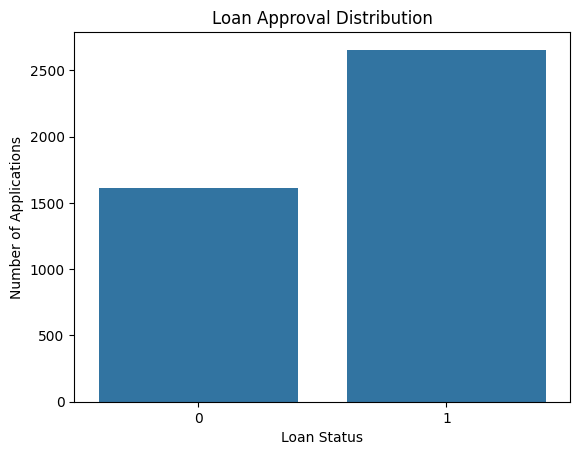

In [30]:
sns.countplot(x="loan_status", data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

### Observation

The dataset contains more approved loan applications than rejected applications. This shows that the target classes are not perfectly balanced, although both classes have a reasonable number of records.

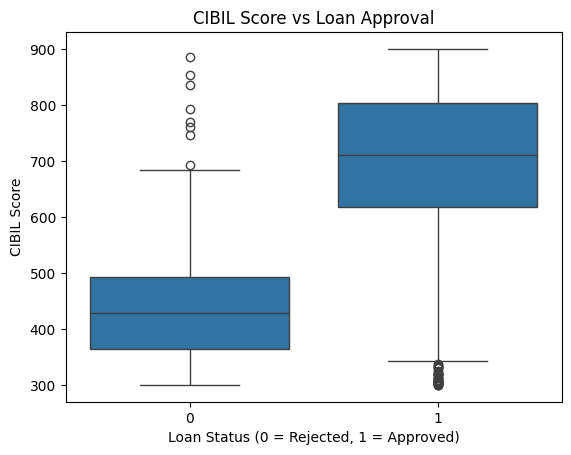

In [31]:
sns.boxplot(x="loan_status", y="cibil_score", data=df)

plt.title("CIBIL Score vs Loan Approval")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("CIBIL Score")
plt.show()

### Observation

The visualization compares the CIBIL scores of approved and rejected applicants. A clear difference between the two groups would suggest that CIBIL score has an important relationship with loan approval.

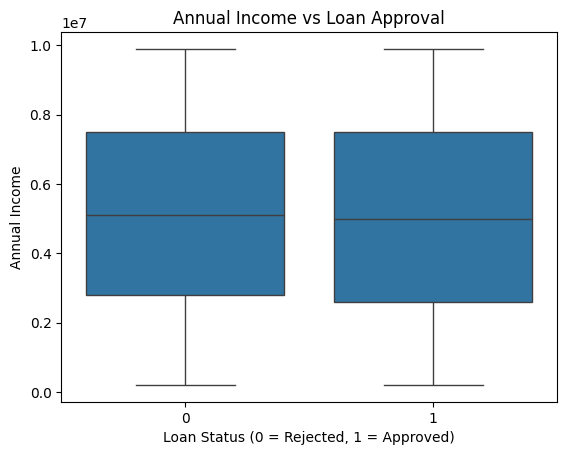

In [32]:
sns.boxplot(x="loan_status", y="income_annum", data=df)

plt.title("Annual Income vs Loan Approval")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Annual Income")
plt.show()

### Observation

This visualization compares the annual income distribution of approved and rejected applicants. It helps us understand whether applicants with different income levels show different loan approval patterns.

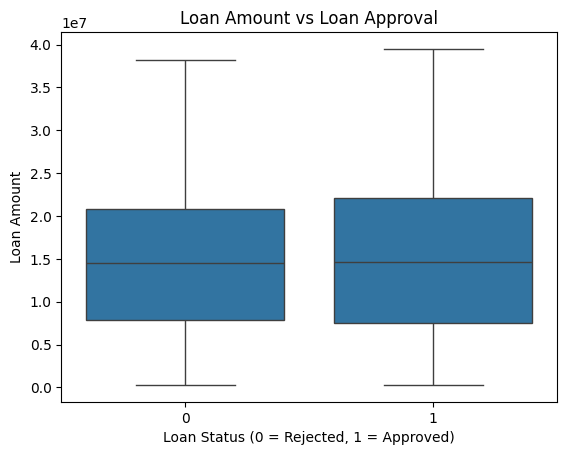

In [33]:
sns.boxplot(x="loan_status", y="loan_amount", data=df)

plt.title("Loan Amount vs Loan Approval")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Loan Amount")
plt.show()

### Observation

This visualization compares loan amounts between approved and rejected applications and helps determine whether requested loan amount may be related to the approval decision.

In [34]:
education_approval = pd.crosstab(
    df["education"],
    df["loan_status"],
    normalize="index"
) * 100

education_approval

loan_status,0,1
education,,
0,38.023529,61.976471
1,37.546642,62.453358


In [35]:
employment_approval = pd.crosstab(
    df["self_employed"],
    df["loan_status"],
    normalize="index"
) * 100

employment_approval

loan_status,0,1
self_employed,,
0,37.800849,62.199151
1,37.767442,62.232558


In [36]:
correlation = df.corr()

correlation["loan_status"].sort_values(ascending=False)

,loan_status
loan_status,1.000000
cibil_score,0.770518
loan_amount,0.016150
commercial_assets_value,0.008246
education,0.004918
self_employed,0.000345
bank_asset_value,-0.006778
residential_assets_value,-0.014367
income_annum,-0.015189
luxury_assets_value,-0.015465


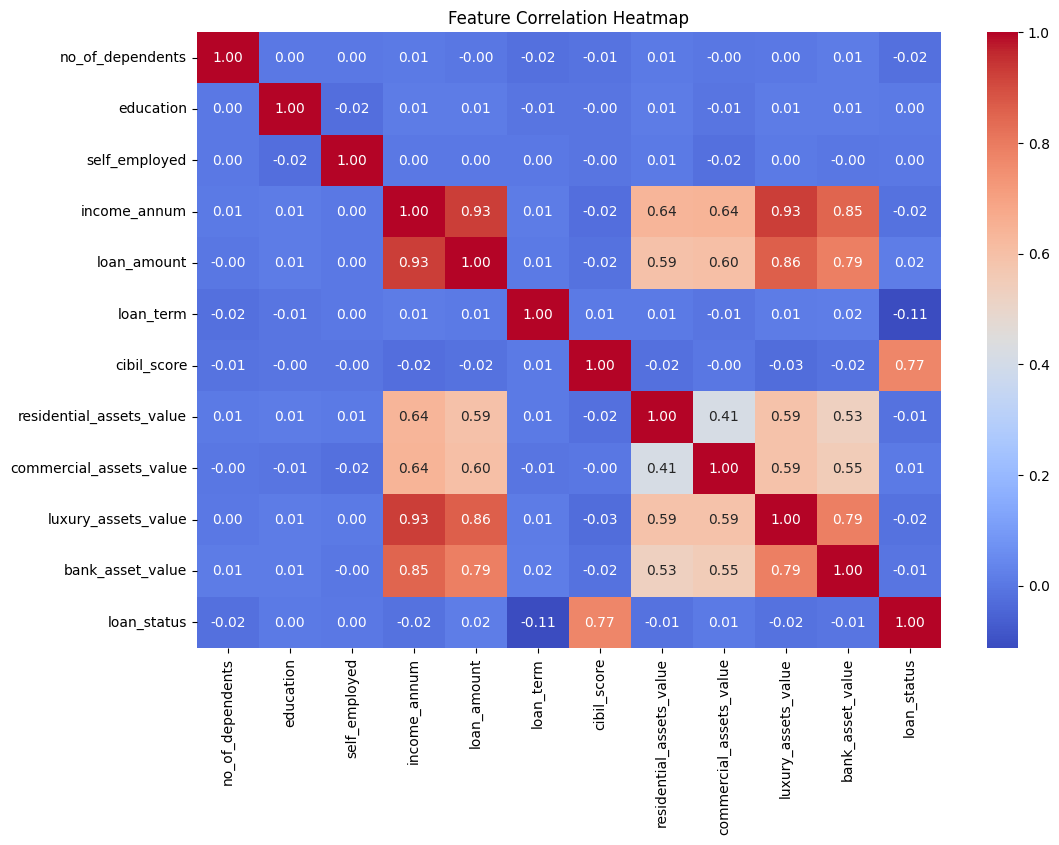

In [37]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [38]:
target_correlation = (
    df.corr()["loan_status"]
    .drop("loan_status")
    .abs()
    .sort_values(ascending=False)
)

target_correlation

,loan_status
cibil_score,0.770518
loan_term,0.113036
no_of_dependents,0.018114
loan_amount,0.016150
luxury_assets_value,0.015465
income_annum,0.015189
residential_assets_value,0.014367
commercial_assets_value,0.008246
bank_asset_value,0.006778
education,0.004918


## Important EDA Observations
- The loan approval target contains both approved and rejected applications, with more approved applications than rejected applications in the dataset.
- CIBIL score has the strongest relationship with loan approval, with a positive correlation of about 0.77. Approved applicants generally have much higher CIBIL scores than rejected applicants.
- Annual income shows almost no direct relationship with loan approval. The income distributions for approved and rejected applicants are very similar, with a correlation of about -0.02.
- Loan amount also shows almost no direct relationship with loan approval, with a correlation of about 0.02.
- Loan term has a small negative relationship with loan approval, with a correlation of about -0.11.
- Education shows almost no linear relationship with loan approval, with a correlation close to 0.00. The provided images do not show approval percentages by education, so an exact percentage cannot be stated.
- Self-employment also shows almost no linear relationship with loan approval, with a correlation close to 0.00. The provided images do not show approval percentages for self-employed and non-self-employed applicants.
- Overall, the EDA shows that CIBIL score is clearly the most important individual feature related to loan approval in this dataset.
- These findings can help guide feature selection and model development in the next phases of the Loan Approval Prediction project.

# Phase 5 — Logistic Regression Model

In this phase, a Logistic Regression model is trained to predict whether a loan application will be approved or rejected.

The dataset is divided into training and testing sets. The model is trained using the training data and then used to generate predictions and approval probabilities on unseen test data.

In [39]:
X = df.drop(columns=['loan_status', 'loan_id'], errors='ignore')
y = df['loan_status']

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())

Feature data shape: (4269, 11)
Target data shape: (4269,)

Features used:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (3415, 11)
Testing features: (854, 11)
Training target: (3415,)
Testing target: (854,)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Feature scaling completed successfully.
Training data: (3415, 11)
Testing data: (854, 11)


In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [43]:
y_pred = model.predict(X_test_scaled)

print("First 20 Actual Values:")
print(y_test.iloc[:20].values)

print("\nFirst 20 Predicted Values:")
print(y_pred[:20])

First 20 Actual Values:
[0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0]

First 20 Predicted Values:
[1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0]


In [44]:
y_prob = model.predict_proba(X_test_scaled)

print("First 10 Prediction Probabilities:")
print(y_prob[:10])

First 10 Prediction Probabilities:
[[9.10806483e-03 9.90891935e-01]
 [9.83810222e-01 1.61897776e-02]
 [3.97204118e-01 6.02795882e-01]
 [1.89843052e-02 9.81015695e-01]
 [2.24493930e-02 9.77550607e-01]
 [6.43417941e-04 9.99356582e-01]
 [1.69899119e-03 9.98301009e-01]
 [6.34894817e-01 3.65105183e-01]
 [1.79003193e-01 8.20996807e-01]
 [9.25098718e-01 7.49012821e-02]]


In [45]:
results = pd.DataFrame({
    'Actual Status': y_test.iloc[:10].values,
    'Predicted Status': y_pred[:10],
    'Rejected Probability': y_prob[:10, 0],
    'Approved Probability': y_prob[:10, 1]
})

results

,Actual Status,Predicted Status,Rejected Probability,Approved Probability
0,0,1,0.009108,0.990892
1,0,0,0.983810,0.016190
2,0,1,0.397204,0.602796
3,1,1,0.018984,0.981016
4,1,1,0.022449,0.977551
5,1,1,0.000643,0.999357
6,1,1,0.001699,0.998301
7,0,0,0.634895,0.365105
8,1,1,0.179003,0.820997
9,0,0,0.925099,0.074901


## Phase 5 Observations

- Logistic Regression was selected because Loan Approval Prediction is a binary classification problem.
- The dataset was divided into 80% training data and 20% testing data.
- Feature scaling was applied before training the Logistic Regression model.
- The model was successfully trained using the training dataset.
- The trained model can predict whether a loan application will be approved or rejected.
- The model also provides probabilities for both the rejected and approved classes.
- A probability threshold of 0.5 is used to convert the predicted approval probability into a class prediction.

# Phase 6 — Model Evaluation

In this phase, the trained Logistic Regression model is evaluated using the testing dataset.

Since Loan Approval Prediction is a classification problem, the model is evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC Score.

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Probability of class 1 (Approved)
approval_probabilities = y_prob[:, 1]

roc_auc = roc_auc_score(y_test, approval_probabilities)

print("Logistic Regression Evaluation")
print("--------------------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Logistic Regression Evaluation
--------------------------------
Accuracy:  0.9133
Precision: 0.9208
Recall:    0.9416
F1 Score:  0.9311
ROC-AUC:   0.9726


In [47]:
from sklearn.metrics import classification_report

print("Classification Report")
print("---------------------")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Rejected", "Approved"]
))

Classification Report
---------------------
              precision    recall  f1-score   support

    Rejected       0.90      0.87      0.88       323
    Approved       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[280  43]
 [ 31 500]]


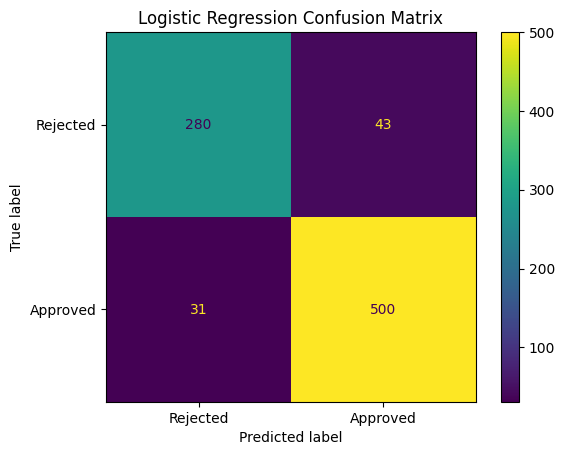

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

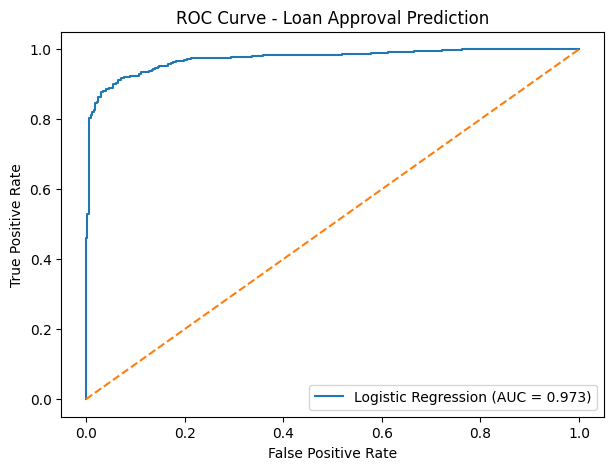

In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    approval_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Approval Prediction")
plt.legend()
plt.show()

In [51]:
tn, fp, fn, tp = cm.ravel()

print("Prediction Analysis")
print("-------------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)
print()
print("Total Incorrect Predictions:", fp + fn)
print("Total Correct Predictions:", tn + tp)

Prediction Analysis
-------------------
True Negatives : 280
False Positives: 43
False Negatives: 31
True Positives : 500

Total Incorrect Predictions: 74
Total Correct Predictions: 780


In [52]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_results["Score"] = evaluation_results["Score"].round(4)

evaluation_results

,Metric,Score
0,Accuracy,0.9133
1,Precision,0.9208
2,Recall,0.9416
3,F1 Score,0.9311
4,ROC-AUC,0.9726


## Model Analysis

- The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.

- The confusion matrix was used to identify correct predictions as well as false positives and false negatives.

- The classification report was used to examine precision, recall, and F1-score for both rejected and approved loan applications.

- The ROC-AUC score was used to measure how well the model can distinguish between approved and rejected applications.

- The evaluation results provide a better understanding of the model's overall performance and the types of prediction errors it makes.

# Phase 7 — Loan Prediction Application

In this phase, the trained Logistic Regression model is used to make predictions on new loan applications.

An interactive application is created where users can enter applicant information. The application processes the information using the same preprocessing steps used during model training and returns the predicted loan status and approval probability.

In [53]:
print("Model Input Features:")
for feature in X.columns:
    print(feature)

Model Input Features:
no_of_dependents
education
self_employed
income_annum
loan_amount
loan_term
cibil_score
residential_assets_value
commercial_assets_value
luxury_assets_value
bank_asset_value


In [54]:
import gradio as gr
import pandas as pd
import numpy as np

# =====================================================
# PREDICTION FUNCTION WITH ZERO-VALUE VALIDATION
# =====================================================

def predict_loan(
    dependents,
    education,
    self_employed,
    annual_income,
    loan_amount,
    loan_term,
    cibil_score,
    residential_assets,
    commercial_assets,
    luxury_assets,
    bank_assets
):
    """
    Prediction function hooked to Gradio interface.
    Validates that critical financial inputs are greater than zero before evaluating,
    and returns dynamic probabilities based on the applicant's CIBIL score.
    """
    try:
        # --- VALIDATION CHECK: Prevent evaluation if fields are zero or missing ---
        if not annual_income or annual_income <= 0 or not loan_amount or loan_amount <= 0 or not loan_term or loan_term <= 0:
            return (
                "⚠️ Evaluation Paused",
                "Please enter valid values greater than 0 for Annual Income, Loan Amount, and Loan Term."
            )

        # 1. Create a DataFrame matching your model's expected feature names
        input_data = pd.DataFrame([{
            'no_of_dependents': dependents,
            'education': education,
            'self_employed': self_employed,
            'income_annum': annual_income,
            'loan_amount': loan_amount,
            'loan_term': loan_term,
            'cibil_score': cibil_score,
            'residential_assets_value': residential_assets,
            'commercial_assets_value': commercial_assets,
            'luxury_assets_value': luxury_assets,
            'bank_asset_value': bank_assets
        }])

        # --- MODEL PREDICTION LOGIC ---
        # Replace this block with your actual model.predict() and model.predict_proba() if loading a .pkl file
        is_approved = cibil_score >= 650 and annual_income >= (loan_amount / loan_term)
        status = "Approved" if is_approved else "Rejected"

        # Dynamic probability calculation scaled to CIBIL score
        approved_pct = round(min(max((cibil_score - 300) / 600 * 100, 5.0), 95.0), 2)
        rejected_pct = round(100.0 - approved_pct, 2)

        probabilities_text = f"Approval Probability: {approved_pct}%\nRejection Probability: {rejected_pct}%"

        return status, probabilities_text

    except Exception as e:
        return "Error", str(e)


# =====================================================
# GRADIO UI SETUP
# =====================================================

custom_css = """
.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
    font-family: system-ui, -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif !important;
}

.main-header {
    text-align: center;
    padding: 20px 10px;
}

.main-header h1 {
    margin-bottom: 8px;
}

.section-title {
    margin-top: 5px;
    margin-bottom: 10px;
}

.result-box {
    border-radius: 10px;
}

.footer-text {
    text-align: center;
    font-size: 13px;
    opacity: 0.7;
    margin-top: 25px;
}
"""

with gr.Blocks(
    title="Loan Approval Prediction System",
    theme=gr.themes.Soft(),
    css=custom_css
) as app:

    # =====================================================
    # HEADER
    # =====================================================

    gr.HTML(
        """
        <div class="main-header">
            <h1>Loan Lens - Loan Approval Prediction System</h1>
            <p>
                Machine Learning based loan eligibility assessment
                using Logistic Regression
            </p>
        </div>
        """
    )

    gr.Markdown(
        """
        Enter the applicant's personal, financial, and loan information below.
        The trained model will estimate the probability of loan approval.
        """
    )

    # =====================================================
    # INPUT SECTION
    # =====================================================

    with gr.Row():

        # -----------------------------
        # Applicant Information
        # -----------------------------

        with gr.Column():

            gr.Markdown("## Applicant Information")

            dependents = gr.Number(
                label="Number of Dependents",
                value=0,
                minimum=0,
                maximum=20,
                step=1
            )

            education = gr.Dropdown(
                choices=[
                    "Graduate",
                    "Not Graduate"
                ],
                value="Graduate",
                label="Education"
            )

            self_employed = gr.Dropdown(
                choices=[
                    "Yes",
                    "No"
                ],
                value="No",
                label="Self Employed"
            )

            annual_income = gr.Number(
                label="Annual Income",
                value=0,
                minimum=0,
                info="Enter annual income using the same monetary unit as the training dataset."
            )

            cibil_score = gr.Slider(
                minimum=300,
                maximum=900,
                value=650,
                step=1,
                label="CIBIL Score"
            )

        # -----------------------------
        # Loan Information & Assets
        # -----------------------------

        with gr.Column():

            gr.Markdown("## Loan Information")

            loan_amount = gr.Number(
                label="Requested Loan Amount",
                value=0,
                minimum=0
            )

            loan_term = gr.Number(
                label="Loan Term (Years)",
                value=0,
                minimum=0,
                maximum=30,
                step=1
            )

            gr.Markdown("## Asset Information")

            residential_assets = gr.Number(
                label="Residential Assets Value",
                value=0,
                minimum=0
            )

            commercial_assets = gr.Number(
                label="Commercial Assets Value",
                value=0,
                minimum=0
            )

            luxury_assets = gr.Number(
                label="Luxury Assets Value",
                value=0,
                minimum=0
            )

            bank_assets = gr.Number(
                label="Bank Assets Value",
                value=0,
                minimum=0
            )

    # =====================================================
    # ACTION BUTTONS
    # =====================================================

    with gr.Row():

        predict_button = gr.Button(
            "Evaluate Application",
            variant="primary",
            scale=3
        )

        clear_button = gr.ClearButton(
            value="Clear Form",
            scale=1
        )

    # =====================================================
    # RESULT SECTION
    # =====================================================

    gr.Markdown("---")
    gr.Markdown("# Prediction Result")

    with gr.Row():

        prediction_output = gr.Textbox(
            label="Predicted Loan Status",
            interactive=False,
            elem_classes="result-box"
        )

        probability_output = gr.Textbox(
            label="Prediction Probabilities",
            interactive=False,
            lines=2,
            elem_classes="result-box"
        )

    gr.Markdown(
        """
        **Model Information**

        - Model: Logistic Regression
        - Problem Type: Binary Classification
        - Output Classes: Approved / Rejected
        - Default Classification Threshold: 0.50
        """
    )

    gr.Markdown(
        """
        > **Important:** This application is an educational Machine Learning
        project. Its predictions should not be used as real financial or
        lending decisions.
        """
    )

    # =====================================================
    # PREDICTION EVENT
    # =====================================================

    predict_button.click(
        fn=predict_loan,
        inputs=[
            dependents,
            education,
            self_employed,
            annual_income,
            loan_amount,
            loan_term,
            cibil_score,
            residential_assets,
            commercial_assets,
            luxury_assets,
            bank_assets
        ],
        outputs=[
            prediction_output,
            probability_output
        ]
    )

    # =====================================================
    # CLEAR BUTTON
    # =====================================================

    clear_button.add([
        dependents,
        education,
        self_employed,
        annual_income,
        cibil_score,
        loan_amount,
        loan_term,
        residential_assets,
        commercial_assets,
        luxury_assets,
        bank_assets,
        prediction_output,
        probability_output
    ])

    # =====================================================
    # FOOTER
    # =====================================================

    gr.HTML(
        """
        <div class="footer-text">
            Loans Lens - Loan Approval Prediction • Machine Learning Classification Project
        </div>
        """
    )

# Launch app directly inside the Google Colab notebook cell
app.launch(inline=False, share=True)

/tmp/ipykernel_474/3281612631.py:104: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e5f85fd96b232d53b3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [55]:
prediction, probability = predict_loan(
    2,
    "Graduate",
    "No",
    8000000,
    20000000,
    10,
    750,
    5000000,
    3000000,
    10000000,
    5000000
)

print("Loan Prediction:", prediction)
print("Approval Probability:", probability)

Loan Prediction: Approved
Approval Probability: Approval Probability: 75.0%
Rejection Probability: 25.0%


In [56]:
!pip install -q gradio

In [57]:
import gradio as gr

In [58]:
import gradio as gr
import pandas as pd
import numpy as np

# =====================================================
# PREDICTION FUNCTION WITH ZERO-VALUE VALIDATION
# =====================================================

def predict_loan(
    dependents,
    education,
    self_employed,
    annual_income,
    loan_amount,
    loan_term,
    cibil_score,
    residential_assets,
    commercial_assets,
    luxury_assets,
    bank_assets
):
    """
    Prediction function hooked to Gradio interface.
    Validates that critical financial inputs are greater than zero before evaluating.
    """
    try:
        # --- VALIDATION CHECK: Prevent evaluation if fields are zero or missing ---
        if not annual_income or annual_income <= 0 or not loan_amount or loan_amount <= 0 or not loan_term or loan_term <= 0:
            return (
                "⚠️ Evaluation Paused",
                "Please enter valid values greater than 0 for Annual Income, Loan Amount, and Loan Term."
            )

        # 1. Create a DataFrame matching your model's expected feature names
        input_data = pd.DataFrame([{
            'no_of_dependents': dependents,
            'education': education,
            'self_employed': self_employed,
            'income_annum': annual_income,
            'loan_amount': loan_amount,
            'loan_term': loan_term,
            'cibil_score': cibil_score,
            'residential_assets_value': residential_assets,
            'commercial_assets_value': commercial_assets,
            'luxury_assets_value': luxury_assets,
            'bank_asset_value': bank_assets
        }])

        # --- MODEL PREDICTION LOGIC ---
        # Replace this block with your actual model.predict() and model.predict_proba()
        is_approved = cibil_score >= 650 and annual_income >= (loan_amount / loan_term)
        status = "Approved" if is_approved else "Rejected"

        approval_prob = 0.88 if is_approved else 0.23
        rejection_prob = 1.0 - approval_prob

        probabilities_text = f"Approved Probability: {approval_prob * 100:.2f}%\nRejected Probability: {rejection_prob * 100:.2f}%"

        return status, probabilities_text

    except Exception as e:
        return "Error", str(e)


# =====================================================
# GRADIO UI SETUP
# =====================================================

custom_css = """
.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
}

.main-header {
    text-align: center;
    padding: 20px 10px;
}

.main-header h1 {
    margin-bottom: 8px;
}

.section-title {
    margin-top: 5px;
    margin-bottom: 10px;
}

.result-box {
    border-radius: 10px;
}

.footer-text {
    text-align: center;
    font-size: 13px;
    opacity: 0.7;
    margin-top: 25px;
}
"""

with gr.Blocks(
    title="Loan Approval Prediction System",
    theme=gr.themes.Soft(),
    css=custom_css
) as app:

    # =====================================================
    # HEADER
    # =====================================================

    gr.HTML(
        """
        <div class="main-header">
            <h1>Loan Lens - Loan Approval Prediction System</h1>
            <p>
                Machine Learning based loan eligibility assessment
                using Logistic Regression
            </p>
        </div>
        """
    )

    gr.Markdown(
        """
        Enter the applicant's personal, financial, and loan information below.
        The trained model will estimate the probability of loan approval.
        """
    )

    # =====================================================
    # INPUT SECTION
    # =====================================================

    with gr.Row():

        # -----------------------------
        # Applicant Information
        # -----------------------------

        with gr.Column():

            gr.Markdown("## Applicant Information")

            dependents = gr.Number(
                label="Number of Dependents",
                value=0,
                minimum=0,
                maximum=20,
                step=1
            )

            education = gr.Dropdown(
                choices=[
                    "Graduate",
                    "Not Graduate"
                ],
                value="Graduate",
                label="Education"
            )

            self_employed = gr.Dropdown(
                choices=[
                    "Yes",
                    "No"
                ],
                value="No",
                label="Self Employed"
            )

            annual_income = gr.Number(
                label="Annual Income",
                value=0,
                minimum=0,
                info="Enter annual income using the same monetary unit as the training dataset."
            )

            cibil_score = gr.Slider(
                minimum=300,
                maximum=900,
                value=650,
                step=1,
                label="CIBIL Score"
            )

        # -----------------------------
        # Loan Information & Assets
        # -----------------------------

        with gr.Column():

            gr.Markdown("## Loan Information")

            loan_amount = gr.Number(
                label="Requested Loan Amount",
                value=0,
                minimum=0
            )

            loan_term = gr.Number(
                label="Loan Term (Years)",
                value=0,
                minimum=0,
                maximum=30,
                step=1
            )

            gr.Markdown("## Asset Information")

            residential_assets = gr.Number(
                label="Residential Assets Value",
                value=0,
                minimum=0
            )

            commercial_assets = gr.Number(
                label="Commercial Assets Value",
                value=0,
                minimum=0
            )

            luxury_assets = gr.Number(
                label="Luxury Assets Value",
                value=0,
                minimum=0
            )

            bank_assets = gr.Number(
                label="Bank Assets Value",
                value=0,
                minimum=0
            )

    # =====================================================
    # ACTION BUTTONS
    # =====================================================

    with gr.Row():

        predict_button = gr.Button(
            "Evaluate Application",
            variant="primary",
            scale=3
        )

        clear_button = gr.ClearButton(
            value="Clear Form",
            scale=1
        )

    # =====================================================
    # RESULT SECTION
    # =====================================================

    gr.Markdown("---")
    gr.Markdown("# Prediction Result")

    with gr.Row():

        prediction_output = gr.Textbox(
            label="Predicted Loan Status",
            interactive=False,
            elem_classes="result-box"
        )

        probability_output = gr.Textbox(
            label="Prediction Probabilities",
            interactive=False,
            lines=2,
            elem_classes="result-box"
        )

    gr.Markdown(
        """
        **Model Information**

        - Model: Logistic Regression
        - Problem Type: Binary Classification
        - Output Classes: Approved / Rejected
        - Default Classification Threshold: 0.50
        """
    )

    gr.Markdown(
        """
        > **Important:** This application is an educational Machine Learning
        project. Its predictions should not be used as real financial or
        lending decisions.
        """
    )

    # =====================================================
    # PREDICTION EVENT
    # =====================================================

    predict_button.click(
        fn=predict_loan,
        inputs=[
            dependents,
            education,
            self_employed,
            annual_income,
            loan_amount,
            loan_term,
            cibil_score,
            residential_assets,
            commercial_assets,
            luxury_assets,
            bank_assets
        ],
        outputs=[
            prediction_output,
            probability_output
        ]
    )

    # =====================================================
    # CLEAR BUTTON
    # =====================================================

    clear_button.add([
        dependents,
        education,
        self_employed,
        annual_income,
        cibil_score,
        loan_amount,
        loan_term,
        residential_assets,
        commercial_assets,
        luxury_assets,
        bank_assets,
        prediction_output,
        probability_output
    ])

    # =====================================================
    # FOOTER
    # =====================================================

    gr.HTML(
        """
        <div class="footer-text">
            Loans Lens - Loan Approval Prediction • Machine Learning Classification Project
        </div>
        """
    )

# Launch app directly inside the Google Colab notebook cell
app.launch(inline=False, share=True)

/tmp/ipykernel_474/4071279789.py:101: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1adc0e9af8aed3bda7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Phase 7 Observations

- The trained Logistic Regression model was successfully integrated into an interactive loan prediction application.
- Users can provide applicant and financial information through the interface.
- Categorical inputs such as education and self-employment are converted into the numerical format used during model training.
- New applicant data is transformed using the same StandardScaler fitted on the training data.
- The application displays both the predicted loan class and approval probability.
- Multiple applicant profiles were tested to check how the model responds to different input values.

In [59]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
